In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import f1_score, mean_absolute_error
import matplotlib.pyplot as plt
import json
from pathlib import Path

# Cargar datos — desde carpeta processed relativa a Notebooks
DATA_DIR = Path("..") / "Data" / "processed"
train = pd.read_csv(DATA_DIR / "train.csv")
val   = pd.read_csv(DATA_DIR / "val.csv")
test  = pd.read_csv(DATA_DIR / "test.csv")

# Device
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Device: {device}")
print(f"Train: {len(train):,} | Val: {len(val):,} | Test: {len(test):,}")

Device: cpu
Train: 70,000 | Val: 15,000 | Test: 15,000


In [2]:
from collections import Counter
import re

# Tokenizador simple
def tokenizar(texto):
    if not isinstance(texto, str):
        return []
    texto = texto.lower()
    tokens = re.findall(r"\b[a-z]+\b", texto)
    return tokens

# Construir vocabulario sobre train
print("Construyendo vocabulario...")
contador = Counter()
for texto in train["review_text"]:
    contador.update(tokenizar(texto))

# Quedarnos con las 20,000 palabras más frecuentes
VOCAB_SIZE = 20_000
vocab = ["<PAD>", "<UNK>"] + [w for w, _ in contador.most_common(VOCAB_SIZE - 2)]
word2idx = {w: i for i, w in enumerate(vocab)}

print(f"Vocabulario: {len(vocab):,} tokens")
print(f"Palabras más comunes: {[w for w, _ in contador.most_common(10)]}")

Construyendo vocabulario...
Vocabulario: 20,000 tokens
Palabras más comunes: ['the', 'i', 'and', 'to', 'a', 'of', 'it', 'that', 'was', 'this']
Vocabulario: 20,000 tokens
Palabras más comunes: ['the', 'i', 'and', 'to', 'a', 'of', 'it', 'that', 'was', 'this']


In [3]:
# Parámetros
MAX_LEN     = 256  # máximo de tokens por reseña
BATCH_SIZE  = 64

def texto_a_indices(texto, max_len=MAX_LEN):
    tokens = tokenizar(texto)[:max_len]
    indices = [word2idx.get(t, 1) for t in tokens]  # 1 = <UNK>
    # Padding
    indices += [0] * (max_len - len(indices))        # 0 = <PAD>
    return indices

class GoodreadsSeqDataset(Dataset):
    def __init__(self, df):
        self.X        = [texto_a_indices(t) for t in df["review_text"]]
        self.y_rating  = (df["rating"] - 1).values
        self.y_spoiler = df["has_spoiler"].astype(float).values
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return (
            torch.tensor(self.X[idx],        dtype=torch.long),
            torch.tensor(self.y_rating[idx],  dtype=torch.long),
            torch.tensor(self.y_spoiler[idx], dtype=torch.float32)
        )

print("Creando datasets (esto tarda un momento)...")
train_dataset = GoodreadsSeqDataset(train)
val_dataset   = GoodreadsSeqDataset(val)
test_dataset  = GoodreadsSeqDataset(test)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

print(f"Batches train: {len(train_loader)}")
print(f"Batches val:   {len(val_loader)}")

Creando datasets (esto tarda un momento)...
Batches train: 1094
Batches val:   235
Batches train: 1094
Batches val:   235


In [4]:
# Arquitectura BiLSTM Multitarea
class BiLSTMMultitask(nn.Module):
    def __init__(self, vocab_size=20_000, embed_dim=128, hidden_dim=128):
        super().__init__()
        
        # Embedding entrenable
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        
        # Encoder compartido — 2 capas BiLSTM
        self.lstm1 = nn.LSTM(
            embed_dim, hidden_dim,
            batch_first=True,
            bidirectional=True
        )
        self.lstm2 = nn.LSTM(
            hidden_dim * 2, 64,
            batch_first=True,
            bidirectional=True
        )
        self.dropout = nn.Dropout(0.4)
        
        # Cabeza Tarea 1 — Rating
        self.head_rating = nn.Sequential(
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 5)
        )
        
        # Cabeza Tarea 2 — Spoiler
        self.head_spoiler = nn.Sequential(
            nn.Linear(128, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )
    
    def forward(self, x):
        # Embedding
        emb = self.embedding(x)
        
        # BiLSTM capas
        out1, _ = self.lstm1(emb)
        out2, _ = self.lstm2(out1)
        
        # Tomar el último estado
        features = self.dropout(out2[:, -1, :])
        
        rating  = self.head_rating(features)
        spoiler = self.head_spoiler(features)
        return rating, spoiler

model_lstm = BiLSTMMultitask().to(device)
total_params = sum(p.numel() for p in model_lstm.parameters())
print(model_lstm)
print(f"\nTotal parámetros: {total_params:,}")

BiLSTMMultitask(
  (embedding): Embedding(20000, 128, padding_idx=0)
  (lstm1): LSTM(128, 128, batch_first=True, bidirectional=True)
  (lstm2): LSTM(256, 64, batch_first=True, bidirectional=True)
  (dropout): Dropout(p=0.4, inplace=False)
  (head_rating): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=5, bias=True)
  )
  (head_spoiler): Sequential(
    (0): Linear(in_features=128, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=1, bias=True)
  )
)

Total parámetros: 3,001,798


In [5]:
# Configuración de entrenamiento
criterion_rating  = nn.CrossEntropyLoss()
criterion_spoiler = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model_lstm.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, patience=2, factor=0.5
)

# Pesos multitarea
alpha = 0.7  # rating
beta  = 0.3  # spoiler

EPOCHS = 10
history = {"train_loss": [], "val_loss": [], "val_acc_rating": [], "val_f1_spoiler": []}

# Early stopping
best_val_loss = float("inf")
patience_counter = 0
PATIENCE = 3

print("Iniciando entrenamiento BiLSTM...\n")

for epoch in range(EPOCHS):
    # ── Train ──
    model_lstm.train()
    train_loss = 0
    for X_b, y_rat, y_spo in train_loader:
        X_b   = X_b.to(device)
        y_rat = y_rat.to(device)
        y_spo = y_spo.to(device)
        
        optimizer.zero_grad()
        out_rating, out_spoiler = model_lstm(X_b)
        loss = alpha * criterion_rating(out_rating, y_rat) + \
               beta  * criterion_spoiler(out_spoiler.squeeze(), y_spo)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_lstm.parameters(), 1.0)
        optimizer.step()
        train_loss += loss.item()
    
    # ── Validación ──
    model_lstm.eval()
    val_loss = 0
    preds_rating, preds_spoiler = [], []
    true_rating,  true_spoiler  = [], []
    
    with torch.no_grad():
        for X_b, y_rat, y_spo in val_loader:
            X_b   = X_b.to(device)
            y_rat = y_rat.to(device)
            y_spo = y_spo.to(device)
            
            out_rating, out_spoiler = model_lstm(X_b)
            loss = alpha * criterion_rating(out_rating, y_rat) + \
                   beta  * criterion_spoiler(out_spoiler.squeeze(), y_spo)
            val_loss += loss.item()
            
            preds_rating.extend(out_rating.argmax(dim=1).cpu().numpy())
            preds_spoiler.extend((out_spoiler.squeeze() > 0).cpu().numpy())
            true_rating.extend(y_rat.cpu().numpy())
            true_spoiler.extend(y_spo.cpu().numpy())
    
    avg_train = train_loss / len(train_loader)
    avg_val   = val_loss   / len(val_loader)
    acc       = np.mean(np.array(preds_rating) == np.array(true_rating))
    f1        = f1_score(true_spoiler, preds_spoiler, zero_division=0)
    
    history["train_loss"].append(avg_train)
    history["val_loss"].append(avg_val)
    history["val_acc_rating"].append(acc)
    history["val_f1_spoiler"].append(f1)
    
    scheduler.step(avg_val)
    
    print(f"Epoch {epoch+1:02d}/{EPOCHS} | "
          f"Train Loss: {avg_train:.4f} | "
          f"Val Loss: {avg_val:.4f} | "
          f"Acc Rating: {acc:.4f} | "
          f"F1 Spoiler: {f1:.4f}")
    
    # Early stopping
    if avg_val < best_val_loss:
        best_val_loss = avg_val
        torch.save(model_lstm.state_dict(), "bilstm_best.pt")
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"\nEarly stopping en época {epoch+1}")
            break

print("\nEntrenamiento completado ✓")
print(f"Mejor val loss: {best_val_loss:.4f}")

Iniciando entrenamiento BiLSTM...

Epoch 01/10 | Train Loss: 1.1593 | Val Loss: 1.1524 | Acc Rating: 0.2006 | F1 Spoiler: 0.0000
Epoch 01/10 | Train Loss: 1.1593 | Val Loss: 1.1524 | Acc Rating: 0.2006 | F1 Spoiler: 0.0000
Epoch 02/10 | Train Loss: 1.1504 | Val Loss: 1.1417 | Acc Rating: 0.2345 | F1 Spoiler: 0.0000
Epoch 02/10 | Train Loss: 1.1504 | Val Loss: 1.1417 | Acc Rating: 0.2345 | F1 Spoiler: 0.0000
Epoch 03/10 | Train Loss: 1.1215 | Val Loss: 1.0863 | Acc Rating: 0.2985 | F1 Spoiler: 0.0000
Epoch 03/10 | Train Loss: 1.1215 | Val Loss: 1.0863 | Acc Rating: 0.2985 | F1 Spoiler: 0.0000
Epoch 04/10 | Train Loss: 1.0120 | Val Loss: 0.9712 | Acc Rating: 0.3882 | F1 Spoiler: 0.0000
Epoch 04/10 | Train Loss: 1.0120 | Val Loss: 0.9712 | Acc Rating: 0.3882 | F1 Spoiler: 0.0000
Epoch 05/10 | Train Loss: 0.9120 | Val Loss: 0.9050 | Acc Rating: 0.4342 | F1 Spoiler: 0.0000
Epoch 05/10 | Train Loss: 0.9120 | Val Loss: 0.9050 | Acc Rating: 0.4342 | F1 Spoiler: 0.0000
Epoch 06/10 | Train Loss:

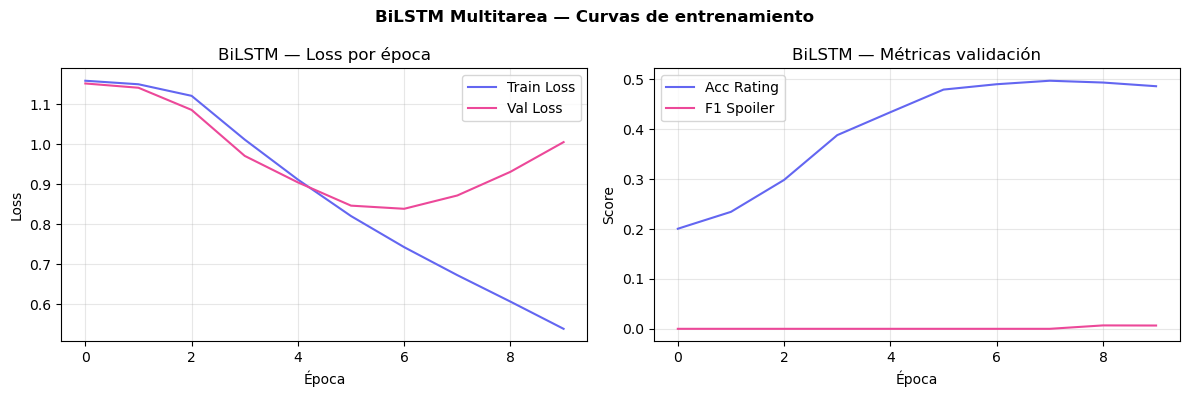

=== RESULTADOS FINALES BiLSTM (Test) ===
Acc Rating:  0.4921
MAE Rating:  0.6573
F1 Spoiler:  0.0135

Resultados guardados: resultados_bilstm.json ✓


In [6]:
# Cargar mejor modelo
model_lstm.load_state_dict(torch.load("bilstm_best.pt"))

# Curvas de entrenamiento
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history["train_loss"], label="Train Loss", color="#6366f1")
axes[0].plot(history["val_loss"],   label="Val Loss",   color="#ec4899")
axes[0].set_title("BiLSTM — Loss por época")
axes[0].set_xlabel("Época")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history["val_acc_rating"], label="Acc Rating", color="#6366f1")
axes[1].plot(history["val_f1_spoiler"], label="F1 Spoiler", color="#ec4899")
axes[1].set_title("BiLSTM — Métricas validación")
axes[1].set_xlabel("Época")
axes[1].set_ylabel("Score")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle("BiLSTM Multitarea — Curvas de entrenamiento", fontweight="bold")
plt.tight_layout()
plt.savefig("bilstm_curves.png", dpi=150, bbox_inches="tight")
plt.show()

# Evaluación en test
model_lstm.eval()
preds_rating, preds_spoiler = [], []
true_rating,  true_spoiler  = [], []

with torch.no_grad():
    for X_b, y_rat, y_spo in test_loader:
        X_b = X_b.to(device)
        out_rating, out_spoiler = model_lstm(X_b)
        preds_rating.extend(out_rating.argmax(dim=1).cpu().numpy())
        preds_spoiler.extend((out_spoiler.squeeze() > 0).cpu().numpy())
        true_rating.extend(y_rat.numpy())
        true_spoiler.extend(y_spo.numpy())

preds_rating = np.array(preds_rating)
true_rating  = np.array(true_rating)

acc = np.mean(preds_rating == true_rating)
mae = mean_absolute_error(true_rating, preds_rating)
f1  = f1_score(true_spoiler, preds_spoiler, zero_division=0)

print("=== RESULTADOS FINALES BiLSTM (Test) ===")
print(f"Acc Rating:  {acc:.4f}")
print(f"MAE Rating:  {mae:.4f}")
print(f"F1 Spoiler:  {f1:.4f}")

# Guardar resultados
resultados_bilstm = {
    "modelo": "BiLSTM Multitarea",
    "acc_rating": round(acc, 4),
    "mae_rating": round(mae, 4),
    "f1_spoiler": round(f1, 4)
}
with open("resultados_bilstm.json", "w") as f:
    json.dump(resultados_bilstm, f, indent=2)

print("\nResultados guardados: resultados_bilstm.json ✓")